In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams.update({'font.size': 20})
import numpy as np
import sys
sys.path.append("/home/jupyter-vincent2/vincent/process_profiles/noteboooks_2026/functions")
from create_rec_datasets import r_analysis_df

/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [3]:
ds_CMA,df_CMA,df_XIEST_CMA,df_PHI_CMA,df_GRID_CMA,df_MU_CMA,df_lambda_CMA = r_analysis_df("CMA_masked")
ds_G,df_G,df_XIEST_G,df_PHI_G,df_GRID_G,df_MU_G,df_lambda_G = r_analysis_df("GLORYS_masked",dense=True)
ds_CL,df_CL,df_XIEST_CL,df_PHI_CL,df_GRID_CL,df_MU_CL,df_lambda_CL = r_analysis_df("GLORYS_CL_masked")

legend_fs = 15
G_color = "#0D160B"
CMA_color = "#008DD5"
CL_color = "#CB152B"

204
204
204


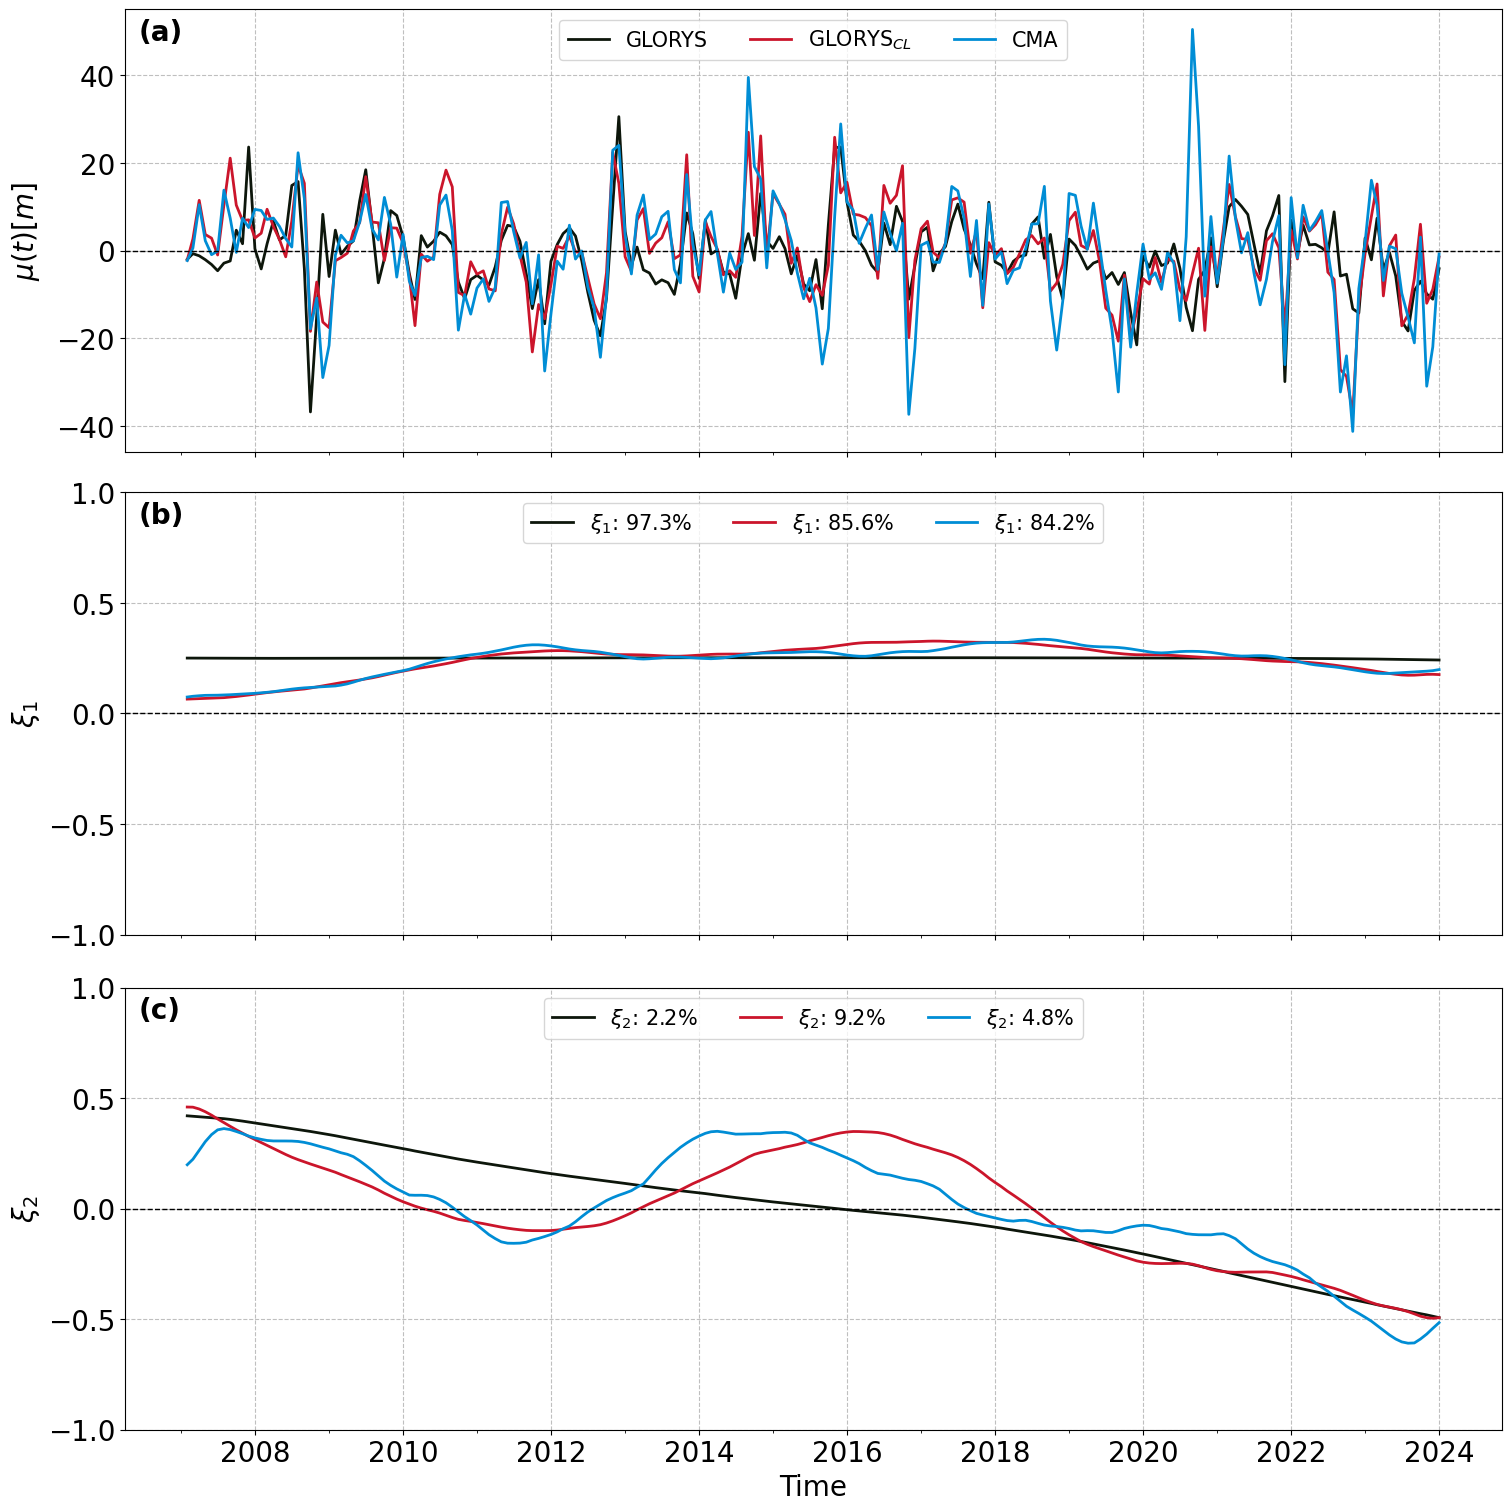

In [4]:
# Variance explained (%) for each mode and each dataset
lambda_map = {
    "GLORYS": df_lambda_G,
    "GLORYS_CL": df_lambda_CL,
    "CMA": df_lambda_CMA,
}
var_exp = {
    name: (100 * df_l.iloc[:, 0] / df_l.iloc[:, 0].sum()).to_numpy()
    for name, df_l in lambda_map.items()
}

# Modes to plot
phi_nums = [1, 2]

fig, axes = plt.subplots(
    1 + len(phi_nums), 1,
    figsize=(15, 15),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.05}
)
if len(phi_nums) == 0:
    axes = [axes]

mu_ax = axes[0]
mode_axes = axes[1:]

datasets = [
    ("GLORYS", ds_G, df_MU_G, G_color),
    ("GLORYS_CL", ds_CL, df_MU_CL, CL_color),
    ("CMA", ds_CMA, df_MU_CMA, CMA_color),
]

# Top subplot: MU time series
for label, _, df_mu, color in datasets:
    mu_ax.plot(df_mu["MU"], color=color, linewidth=2, label=label)

mu_ax.legend(loc="upper center", fontsize=legend_fs, ncol=3,labels=["GLORYS", "GLORYS$_{CL}$", "CMA"])
mu_ax.axhline(0, color="k", linestyle="--", linewidth=1)
mu_ax.set_ylabel("$\\mu (t) [m]$")
mu_ax.text(
    0.01, 0.98, "(a)",
    transform=mu_ax.transAxes,
    ha="left", va="top",
    fontsize=20, fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
)

# Existing phi subplots
for j, n in enumerate(phi_nums):
    ax_i = mode_axes[j]
    var = f"phi{n}"
    var_name = f"$\\xi_{{{n}}}$"
    for label, ds, _, color in datasets:
        if var in ds:
            ve = var_exp[label][n - 1] if n - 1 < len(var_exp[label]) else float("nan")
            ax_i.plot(
                ds.time,
                ds[var],
                color=color,
                linewidth=2,
                label=f"{var_name}: {ve:.1f}%"
            )
    ax_i.legend(loc="upper center", fontsize=legend_fs, ncol=3)
    ax_i.set_ylim(-1, 1)
    ax_i.set_ylabel(f"$\\xi_{{{n}}}$")
    ax_i.axhline(0, color="k", linestyle="--", linewidth=1)
    ax_i.text(
        0.01, 0.98, f"({chr(98 + j)})",
        transform=ax_i.transAxes,
        ha="left", va="top",
        fontsize=20, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
    )
    # ax_i.grid()

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_minor_locator(mdates.YearLocator(1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Time")


for a in axes:
    a.grid(True, linestyle="--", alpha=0.8)

fig.align_ylabels()

fig.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_4_MU_modes.png", bbox_inches="tight", dpi=300)
plt.show()

In [20]:
ds_CMA_og = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_anom.nc").load()
ds_CMA_og.update({"time": ds_CMA.time, "latitude": ds_CMA.lat.values, "longitude": ds_CMA.long.values})
ds_CMA_og = ds_CMA_og.rename({"latitude": "lat", "longitude": "long"})